# Peak Sampling


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.special import logsumexp

from scipy.special import logsumexp
from scipy.signal import correlate
from statsmodels.tsa.stattools import acf
import morphZ
import corner

In [2]:

def log_plus(x,y):
    
    if x > y:
      summ = x + np.log(1+np.exp(y-x))
    else:
        summ = y + np.log(1+np.exp(x-y))
    return summ

def log_sum(vec): 
    r = -np.Inf
    for i in range(len(vec)):
       #print('element:',vec[i])
       r =log_plus(r, vec[i])
       #print(r)
    return r



In [3]:

def lnlikefn(x):
        u = 0.01
        v = 0.1
        x1 = np.sum(-(x**2)/(2*v**2))-len(x)*np.log(np.sqrt(2*np.pi)*v)
        #print(x1)
        x2 = np.sum(-((x-0)**2)/(2*u**2))-len(x)*np.log(np.sqrt(2*np.pi)*u)#+np.log(100)
        #print(x2)
        return log_plus(x1,x2)

def lnpriorfn(x):

    if np.any((x < -0.5) | (x > 0.5)):  # Check if x is outside the cube
        return -np.inf 

    return 0.0 

def lnprobfn(x):
    return lnlikefn(x) + lnpriorfn(x)



In [4]:
import numpy as np
import dynesty
from dynesty import utils as dyfunc

ndim = 20  # number of parameters/dimensions
# nlive = 20 * ndim  # number of live points (analogous to nwalkers)
nlive = 25 * ndim  # number of live points (analogous to nwalkers)



# Define the prior transform: maps a unit cube (0,1) to the prior volume.
# For a uniform prior between -0.5 and 0.5 for each parameter:
def prior_transform(u):
    # u is a 1D array of ndim values in [0, 1]
    return -0.5 + u  # scales u to [-0.5, 0.5]

# Create the nested sampler instance.

# Run the nested sampling.
# Note: print_progress=True shows the progress.
NN = 1

log_z_NS = np.zeros(NN)
log_z_NS_err = np.zeros(NN)

for i in range(NN):
    sampler = dynesty.NestedSampler(lnlikefn, prior_transform, ndim, nlive=nlive)
    sampler.run_nested(dlogz=0.00000001, maxiter=2000000,print_progress=True)
    res = sampler.results
    log_z_NS[i] = res.logz[-1]
    log_z_NS_err[i] = res.logzerr[-1]


# Get posterior samples.
# dynesty provides weighted samples; here we compute equal-weight samples.
samples_ns, weights = res.samples, np.exp(res.logwt - res.logz[-1])
posterior_samples = dyfunc.resample_equal(samples_ns, weights)



45104it [01:22, 545.54it/s, +500 | bound: 586 | nc: 1 | ncall: 1752119 | eff(%):  2.604 | loglstar:   -inf < 73.399 <    inf | logz:  1.702 +/-  0.312 | dlogz:  0.000 >  0.000]


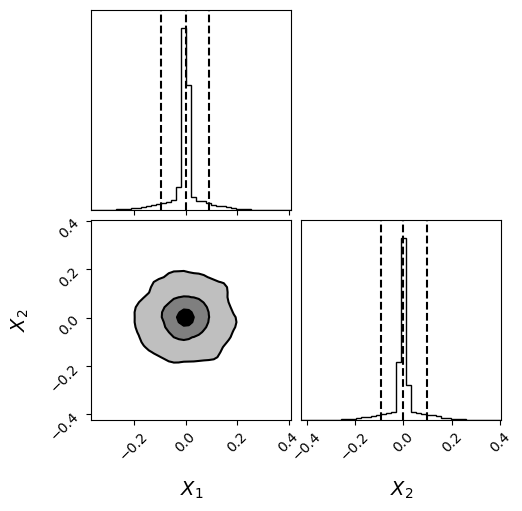

In [6]:

fig = corner.corner(
    posterior_samples[:,:2], bins=40,labels=[r"$X_{1}$",r"$X_{2}$"],label_kwargs = {"fontsize": 14},truth_color="dodgerblue",hist_kwargs={"density": True},quantiles=[0.05, 0.5, 0.95],
    show_titles=False,
    fontzise=24,
    title_fmt=".2f",
    plot_datapoints=False,
    fill_contours=True,
    levels=(0.5, 0.8, 0.95),         
    smooth=1.0  
)

plt.show()

In [12]:
# import logging
# from morphZ import setup_logging; setup_logging(level=logging.INFO)
samples = posterior_samples[::30,:]  # total_samples[::20,:]
tot_len , ndim = samples.shape
print('Total samples:', tot_len, 'Dimensions:', ndim)
log_prob = np.zeros(tot_len)

for i in range(tot_len):
    log_prob[i] = lnprobfn(samples[i,:])

log_p_estimate = morphZ.evidence(
samples,
log_prob,
lnprobfn,
n_resamples=2000,
thin=1,n_estimations=2,morph_type="pair",kde_bw="silverman",plot=False,output_path='./morphZ_peak_sampling_new')
#print('True:', np.log(2))
print('True log(z) for A=1:', np.log(2))
print('MorphZ estimate:', log_p_estimate[0])
print(f'NS log(z): {res.logz[-1]} +/- {res.logzerr[-1]}')


Total samples: 1521 Dimensions: 20


Evaluating proposal samples:   0%|          | 0/2000 [00:00<?, ?it/s]

Evaluating proposal samples:   0%|          | 0/2000 [00:00<?, ?it/s]

True log(z) for A=1: 0.6931471805599453
MorphZ estimate: [0.6998277744777064, 0.261436116805889]
NS log(z): 1.7024361862932529 +/- 0.31207386544757665
